# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 5     |  |
| :-------------|:-------------|
| Batu Sömnez| 6175163 |
| Daniel Roelse| 6527892 |
| Jesse Langenberg| 6290116 |
| Planning Groep: 5     |Tijdstip / Tijdspanne  |
|---|---|
| Sanity check 1 | 11:15 |
| Sanity check 2 | 11:45 |
| Sanity check 3 | 12:30 |
| Pauze 1| 12:30-13:30 |
| Ontwerpen sensor | 13:30-14:30 |
| Simuleren data | 14:30-14:45 |
| Maken sensor | 14:45-15:15 |
| Pauze 2| 15:15-15:45 |
| Kalibreren sensor| 15:45-16:00|
| Afronden opdracht | 16:00-17:30 |


## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="schetstest.jpg" alt="schets student 1" width="400"/>

A = 10*10 cm^2 = 0.01 m^2,

d = 1.5 mm = 0.0015 m

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

epsilon=8.854e-12

# plaatcondensator capaciteit
def vlakkeplaat(A, d, e_r):
    C = e_r * A / d
    return C


# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

#berekening met condensator en karton, 10*10 cm^2 oppervlak, dikte karton = 0.0015 meter, ongeveer 2.3 keer permivilliteit van het vacuum.


print(f"Berekende capaciteit plaatcondensator groep XX is {vlakkeplaat(0.01,0.0015,1.5*epsilon*10**12):.1f} pF")



Berekende capaciteit plaatcondensator groep XX is 88.5 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](testopstelling.jpg)
![scope meting 2](condensatormeting.jpg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 5| 88.5 pF | 256 mV | 258 mV | 51.3 pF  |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](krachtmeter.jpg)
![drie schetsen](positiemeter.jpg)
![drie schetsen](vochtigheidsmeter.jpg)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die gewicht meet. (De krachtmeter dus)

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](totaleschets.jpg)

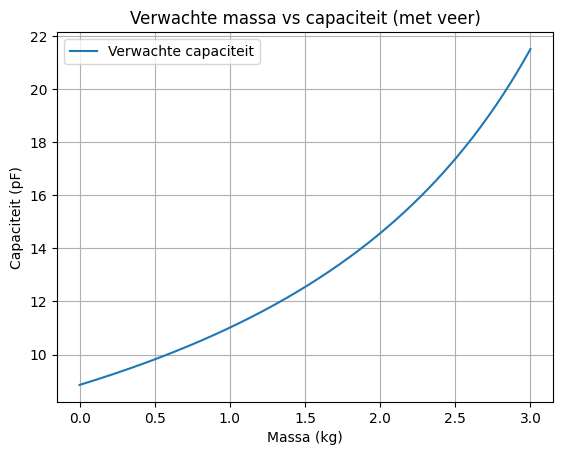

In [3]:

import numpy as np
import matplotlib.pyplot as plt

# Constanten
epsilon0 = 8.854e-12  # permittiviteit vacuüm (F/m)
A = 0.01              # plaatoppervlak (m²)
d0 = 0.01             # beginafstand zonder massa (m)
k = 5000               # veerconstante (N/m)
g = 9.81              # zwaartekracht (m/s²)

# Massa-array (kg)
m = np.linspace(0, 3, 300)

# Indrukking veer
x = (m * g) / k

# Nieuwe plaatafstand
d = d0 - x

# Capaciteit
C = epsilon0 * A / d

# Omzetten naar pF
C_pF = C * 1e12

# Plot
plt.plot(m, C_pF, label="Verwachte capaciteit")
plt.xlabel("Massa (kg)")
plt.ylabel("Capaciteit (pF)")
plt.title("Verwachte massa vs capaciteit (met veer)")
plt.grid()
plt.legend()
plt.show()


## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 21 | 110 |
| gemiddelde capaciteit| 180 | 832 |
| maximale capaciteit| 320 | 1574 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.

De opstelling zonder gewicht:

![meting 1](Meting1.jpg)
![meting 2](Opstelling1.jpg)

De opstelling met gewicht:
![meting 1](Meting.jpg)
![meting 2](OpstellingGewicht1.jpg)

De opstelling van binnen:
![meting 1](OpstellingBinnen1.jpg)


## Opdracht 7: Plot de kalibratiegrafiek.

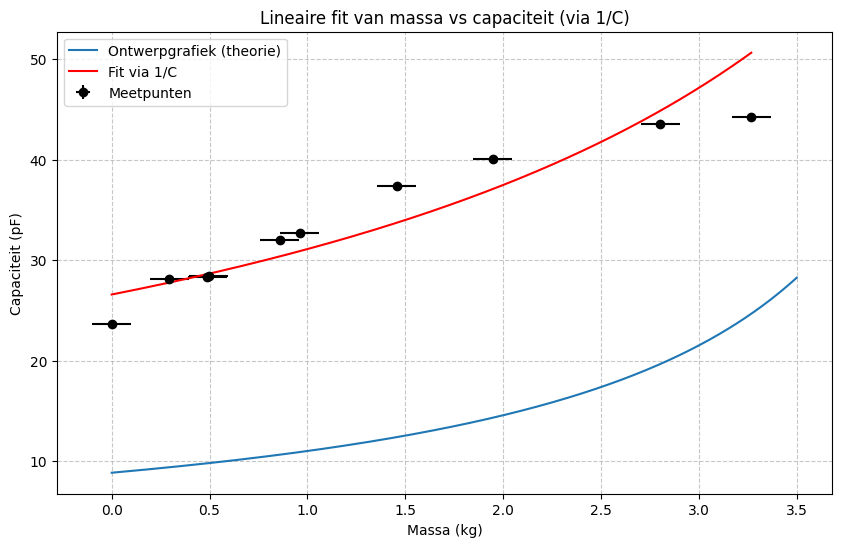

Intercept (1/C bij m=0) : 3.76092e-02 1/pF
Slope (verandering van 1/C met massa) : -5.46720e-03 1/(pF·kg)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# data
massa = np.array([0, 0.2952, 0.4884, 0.8588, 0.961,
                  0.4962, 1.457, 1.946, 2.804, 3.268])

capaciteit = np.array([23.7, 28.1, 28.3, 32.0, 32.7,
                       28.4, 37.4, 40.1, 43.6, 44.3])  # pF

# ontwerpgrafiek
epsilon0 = 8.854e-12  # F/m
A = 0.01               # m²
g = 9.81               # m/s²
m_model = np.linspace(0, 3.5, 400)
x = (m_model * g) / k
d = d0 - x
C_model = epsilon0 * A / d
C_model_pF = C_model * 1e12


# fitfunctie: lineair voor 1/C
def inverse_fit(m, intercept, slope):
    return intercept + slope * m  # y = 1/C

# fitwaardes berekenen
y = 1 / capaciteit
popt, pcov = curve_fit(inverse_fit, massa, y)

intercept_fit, slope_fit = popt


# fit
m_fit = np.linspace(0, max(massa), 300)
C_fit = 1 / inverse_fit(m_fit, intercept_fit, slope_fit)

# errorbars
x_error = 0.1
y_error = 0 #y error wordt niet geplot, door de grootte waardoor de rest van de plot niet meer zichtbaar is


# plotten
plt.figure(figsize=(10,6))
plt.plot(m_model, C_model_pF, label="Ontwerpgrafiek (theorie)")
plt.errorbar(massa, capaciteit, xerr=x_error, yerr=y_error, fmt='o', color='black', label='Meetpunten')
plt.plot(m_fit, C_fit, color='red', label='Fit via 1/C')
plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (pF)')
plt.title('Lineaire fit van massa vs capaciteit (via 1/C)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


print(f"Intercept (1/C bij m=0) : {intercept_fit:.5e} 1/pF")
print(f"Slope (verandering van 1/C met massa) : {slope_fit:.5e} 1/(pF·kg)")


## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* We kunnen meer veertjes gebruiken om de opstelling stabieler te maken. Daardoor zal de oscilloscoop nauwkeurigere resultaten leveren omdat de waardes minder zullen schommelen.
* Grotere platen gebruiken, zodat we een hogere capaciteit kunnen halen. 

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.

Totale opstelling van het ontwerp:
![foto sensor](OpstellingGewicht1.jpg)

## Opdracht 10: Vul hieronder de conclusie in.

Uit de metingen blijkt duidelijk dat de capaciteit van de vlakke plaat condensator toeneemt naarmate er meer massa op de veer wordt geplaatst. Dit is in overeenstemming met de verwachting: het extra gewicht drukt de platen dichter bij elkaar, waardoor de afstand $d$ afneemt en de capaciteit $C = \varepsilon_0 A / d$ stijgt.

De lineaire fit van de inverse capaciteit ($1/C$) versus massa volgt de meetpunten goed, wat bevestigt dat de relatie tussen veeruitrekking en condensatorafstand fysisch correct wordt beschreven door de wet van Hooke. Kleine afwijkingen van de meetpunten ten opzichte van de fit kunnen echter optreden doordat de veerconstante $k$ in de praktijk niet volledig constant is, en door kleine variaties in de beginafstand van de platen.

Het verschil tussen de theoretische ontwerpgrafiek en de experimentele data is eveneens verklaarbaar: het theoretische model gaat uit van ideale omstandigheden, terwijl in de praktijk randvelden, constructieafwijkingen en een licht niet-lineaire veerreactie de gemeten capaciteit iets verhogen. Daarom kunnen we onze condensator goed gebruiken voor het meten van krachten.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.


#Opdracht 4
#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](totaleschets.jpg)

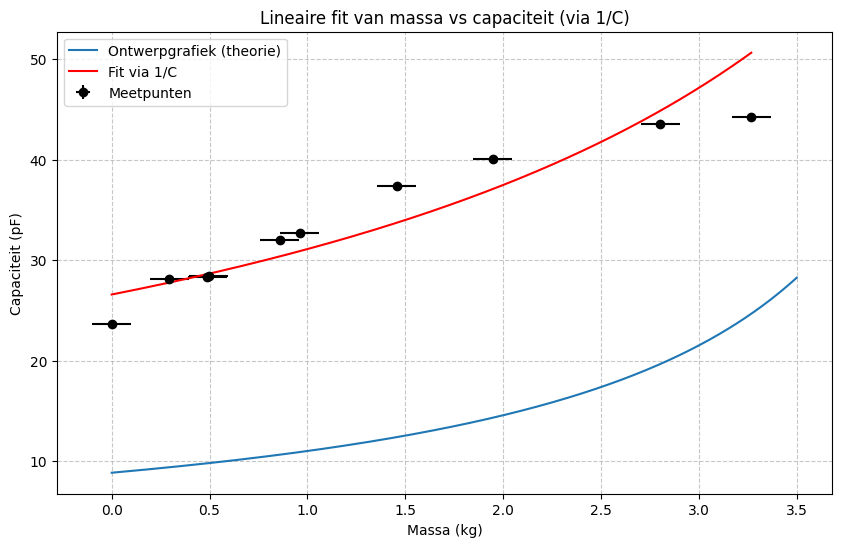

Intercept (1/C bij m=0) : 3.76092e-02 1/pF
Slope (verandering van 1/C met massa) : -5.46720e-03 1/(pF·kg)


In [5]:
# opdracht 7
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# data
massa = np.array([0, 0.2952, 0.4884, 0.8588, 0.961,
                  0.4962, 1.457, 1.946, 2.804, 3.268])

capaciteit = np.array([23.7, 28.1, 28.3, 32.0, 32.7,
                       28.4, 37.4, 40.1, 43.6, 44.3])  # pF

# ontwerpgrafiek
epsilon0 = 8.854e-12  # F/m
A = 0.01               # m²
g = 9.81               # m/s²
m_model = np.linspace(0, 3.5, 400)
x = (m_model * g) / k
d = d0 - x
C_model = epsilon0 * A / d
C_model_pF = C_model * 1e12


# fitfunctie: lineair voor 1/C
def inverse_fit(m, intercept, slope):
    return intercept + slope * m  # y = 1/C

# fitwaardes berekenen
y = 1 / capaciteit
popt, pcov = curve_fit(inverse_fit, massa, y)

intercept_fit, slope_fit = popt


# fit
m_fit = np.linspace(0, max(massa), 300)
C_fit = 1 / inverse_fit(m_fit, intercept_fit, slope_fit)

# errorbars
x_error = 0.1
y_error = 0 #y error wordt niet geplot, door de grootte waardoor de rest van de plot niet meer zichtbaar is


# plotten
plt.figure(figsize=(10,6))
plt.plot(m_model, C_model_pF, label="Ontwerpgrafiek (theorie)")
plt.errorbar(massa, capaciteit, xerr=x_error, yerr=y_error, fmt='o', color='black', label='Meetpunten')
plt.plot(m_fit, C_fit, color='red', label='Fit via 1/C')
plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (pF)')
plt.title('Lineaire fit van massa vs capaciteit (via 1/C)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


print(f"Intercept (1/C bij m=0) : {intercept_fit:.5e} 1/pF")
print(f"Slope (verandering van 1/C met massa) : {slope_fit:.5e} 1/(pF·kg)")


kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

Opdracht 7
#### Voeg hier de foto's van je sensoren in actie in.

De opstelling zonder gewicht:

![meting 1](Meting1.jpg)
![meting 2](Opstelling1.jpg)

De opstelling met gewicht:
![meting 1](Meting.jpg)
![meting 2](OpstellingGewicht1.jpg)

De opstelling van binnen:
![meting 1](OpstellingBinnen1.jpg)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.



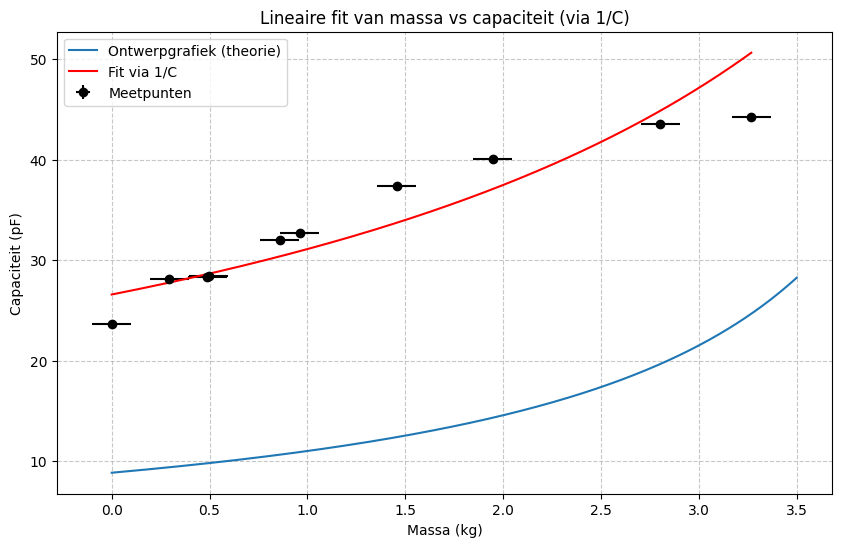

Intercept (1/C bij m=0) : 3.76092e-02 1/pF
Slope (verandering van 1/C met massa) : -5.46720e-03 1/(pF·kg)


In [6]:
#opdracht 7

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# data
massa = np.array([0, 0.2952, 0.4884, 0.8588, 0.961,
                  0.4962, 1.457, 1.946, 2.804, 3.268])

capaciteit = np.array([23.7, 28.1, 28.3, 32.0, 32.7,
                       28.4, 37.4, 40.1, 43.6, 44.3])  # pF

# ontwerpgrafiek
epsilon0 = 8.854e-12  # F/m
A = 0.01               # m²
g = 9.81               # m/s²
m_model = np.linspace(0, 3.5, 400)
x = (m_model * g) / k
d = d0 - x
C_model = epsilon0 * A / d
C_model_pF = C_model * 1e12


# fitfunctie: lineair voor 1/C
def inverse_fit(m, intercept, slope):
    return intercept + slope * m  # y = 1/C

# fitwaardes berekenen
y = 1 / capaciteit
popt, pcov = curve_fit(inverse_fit, massa, y)

intercept_fit, slope_fit = popt


# fit
m_fit = np.linspace(0, max(massa), 300)
C_fit = 1 / inverse_fit(m_fit, intercept_fit, slope_fit)

# errorbars
x_error = 0.1
y_error = 0 #y error wordt niet geplot, door de grootte waardoor de rest van de plot niet meer zichtbaar is


# plotten
plt.figure(figsize=(10,6))
plt.plot(m_model, C_model_pF, label="Ontwerpgrafiek (theorie)")
plt.errorbar(massa, capaciteit, xerr=x_error, yerr=y_error, fmt='o', color='black', label='Meetpunten')
plt.plot(m_fit, C_fit, color='red', label='Fit via 1/C')
plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (pF)')
plt.title('Lineaire fit van massa vs capaciteit (via 1/C)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


print(f"Intercept (1/C bij m=0) : {intercept_fit:.5e} 1/pF")
print(f"Slope (verandering van 1/C met massa) : {slope_fit:.5e} 1/(pF·kg)")


#Opdracht 10

Uit de metingen blijkt duidelijk dat de capaciteit van de vlakke plaat condensator toeneemt naarmate er meer massa op de veer wordt geplaatst. Dit is in overeenstemming met de verwachting: het extra gewicht drukt de platen dichter bij elkaar, waardoor de afstand $d$ afneemt en de capaciteit $C = \varepsilon_0 A / d$ stijgt.

De lineaire fit van de inverse capaciteit ($1/C$) versus massa volgt de meetpunten goed, wat bevestigt dat de relatie tussen veeruitrekking en condensatorafstand fysisch correct wordt beschreven door de wet van Hooke. Kleine afwijkingen van de meetpunten ten opzichte van de fit kunnen echter optreden doordat de veerconstante $k$ in de praktijk niet volledig constant is, en door kleine variaties in de beginafstand van de platen.

Het verschil tussen de theoretische ontwerpgrafiek en de experimentele data is eveneens verklaarbaar: het theoretische model gaat uit van ideale omstandigheden, terwijl in de praktijk randvelden, constructieafwijkingen en een licht niet-lineaire veerreactie de gemeten capaciteit iets verhogen. Daarom kunnen we onze condensator goed gebruiken voor het meten van krachten.